# TP15 - Réservation d'une salle

!!! info Contexte
Le contexte est le suivant : vous êtes gestionnaire d'un centre de conférences. Vous recevez des demandes de réservation pour votre salle principale, de la part de conférenciers. \
Chaque conférencier vous fait une demande pour un créneau horaire, et votre but est de **maximiser le nombre de conférenciers** qui interviendront dans votre salle principale.
!!!

!!! example Exemple
Commençons par un premier exemple. Vous traitez les demandes pour une matinée de quatre heures, de l'heure notée 0 (pour 8h) à l'heure notée 4 (pour 12h).

Vous recevez les demandes de 4 conférenciers $C_1, C_2, C_3$ et $C_4$. Les créneaux horaires demandés par ces conférenciers sont représentés ci-dessous.

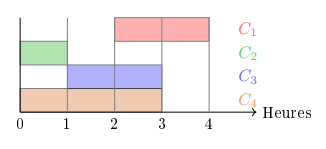

Tenant compte des incompatibilités entre ces demandes, vous dressez la liste des conférenciers que vous pourriez retenir. Vous observez que vos possibilités sont les suivantes :
- Retenir $C_1$ et $C_2$
- Retenir $C_2$ et $C_3$
- Retenir $C_4$

(les autres possibilités étant immédiatement exclues).

Dans le but de maximiser le nombre de conférenciers, les deux premières options sont bonnes mais la troisième
est à exclure.
!!!

## 1. Modélisation du problème

!!! example Modélisation d'une demande de réservation
On représente une demande de réservation par un **3-uplet** contenant un `id` de type `int`, ainsi qu'un `debut` et une `fin` de type `int`. 

Par exmple on représenterait $C_1$ par 
```python 
c_1 = (1, 2, 4) # id = 1, début au créneau 2 et fin au créneau 4
```
!!!
!!! question Question 1
Créer une liste `reservations_1` contenant les 4 demandes de réservation $C_1, C_2, C_3$ et $C_4$ du graphique précédant.
!!!

In [1]:
reservations_1 = [(1,2,4), (2,0,1), (3,1,3), (4,0,3)]

## 2. Stratégies gloutonnes
!!! info Stratégies gloutonnes 
On va voir quelques stratégies gloutonnes permettant de proposer une solution à ce problème.
Le principe commun à ces stratégies est le suivant :
- On classe les conférenciers selon un ordre de préférence,
- puis on remplit notre planning en prenant un à un le conférencier préféré parmi les conférenciers dont le créneau n'entre pas en confit avec ceux déjà choisi.
!!!
### 2.1 
!!! example Stratégie gloutonne 1
On classe les conférenciers par **ordre croissant d'heure de début** de conférence (plus un conférencier commence tôt, plus on veut le choisir).
!!!
!!! question Question 2
Écrire dand un premier temps une fonction de tri `tri_debut_croissant(reservations)` qui va trier les reservations par ordre croissant d'heure de début. 

Mettez en commentaire le nom de l'algorithme de tri que vous avez utilisé et sa complexité.
!!!

In [2]:
i_debut = 1

def merge_debut_croissant(l1, l2):
    i, j = 0, 0
    res = []
    while i < len(l1) and j < len(l2):
        if l1[i][i_debut] <= l2[j][i_debut] : 
            res.append(l1[i])
            i += 1
        else :
            res.append(l2[j])
            j += 1
    res += l1[i:] + l2[j:]
    return res

def tri_debut_croissant(reservations): # tri fusion O(n.log(n))
    if len(reservations) in [0,1]:
        return reservations
    mid = len(reservations)//2
    return merge_debut_croissant(tri_debut_croissant(reservations[:mid]), tri_debut_croissant(reservations[mid:]))

In [3]:
print(tri_debut_croissant(reservations_1))

[(2, 0, 1), (4, 0, 3), (3, 1, 3), (1, 2, 4)]


!!! question Question 3
Implémenter une fonciton `strat_1(reservations)` qui prend en paramètre une liste de réservations et renvoie une liste contenant les réservations prises en compte par la stratégie gloutonne 1 **(par ordre de début croissant)**. 
!!!

In [4]:
i_fin = 2

def strat_1(reservations):
    assert len(reservations) > 0, "la liste de réservations ne doit pas être vide"
    
    reservations = tri_debut_croissant(reservations)
    res = [reservations[0]]
    
    for i in range(1,len(reservations)):
        # si la dernière réservation prise est fini alors on peut prendre la reservation i
        if res[-1][i_fin] <= reservations[i][i_debut]:
            res.append(reservations[i])
    return res

In [5]:
print(strat_1(reservations_1))

[(2, 0, 1), (3, 1, 3)]


!!! question Question 4
La stratégie gloutonne 1 est-elle optimale ? Si non, donner un exemple qui ne renvoie pas un résultat optimal.

_Rappel : on cherche à maximiser le nombre de conférenciers_
!!!

In [6]:
print(strat_1([(1,2,4), (2,1,2), (3,0,3)]))

[(3, 0, 3)]


Non par exemple si on a :
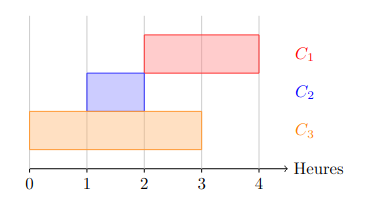
Alors on aura que $C_3$ au lieu de $C_1$ et $C_2$.

### 2.2
!!! example Stratégie gloutonne 2
On classe les conférenciers par **durée croissante de conférence**.
!!!
!!! question Question 5
Reprenez votre fonction de tri de la Q2 pour en faire une fonction `tri_duree_croissante(reservations)`
!!!

In [7]:
i_debut = 1
i_fin = 2
def merge_duree_croissant(l1, l2):
    i, j = 0, 0
    res = []
    while i < len(l1) and j < len(l2):
        if l1[i][i_fin] - l1[i][i_debut] <= l2[j][i_fin] - l2[j][i_debut]  : 
            res.append(l1[i])
            i += 1
        else :
            res.append(l2[j])
            j += 1
    res += l1[i:] + l2[j:]
    return res

def tri_duree_croissante(reservations): # tri fusion O(n.log(n))
    if len(reservations) in [0,1]:
        return reservations
    mid = len(reservations)//2
    return merge_duree_croissant(tri_duree_croissante(reservations[:mid]), tri_duree_croissante(reservations[mid:]))

In [8]:
print(tri_duree_croissante(reservations_1))

[(2, 0, 1), (1, 2, 4), (3, 1, 3), (4, 0, 3)]


!!! question Question 6
Implémenter une fonciton `strat_2(reservations)` qui prend en paramètre une liste de réservations et renvoie une liste contenant les réservations prises en compte par la stratégie gloutonne 2. 
!!!

In [48]:
i_debut = 1
i_fin = 2

def sont_en_collision(c1, c2):
    """Renvoie True ssi c1 et c2 sont en collision"""
    return not (c1[i_fin] <= c2[i_debut] or c1[i_debut] >= c2[i_fin])

def est_en_collision(planning, c):
    """Renvoie vrai si c est en collision avec une conférence de la liste planning"""
    for e in planning:
        if sont_en_collision(e, c):
            return True
    return False

def strat_2(reservations):
    assert len(reservations) > 0, "la liste de réservations ne doit pas être vide"
    
    reservations = tri_duree_croissante(reservations)
    planning = [reservations[0]]
    
    for i in range(1,len(reservations)):
        if not est_en_collision(planning, reservations[i]) :
            planning.append(reservations[i])
    
    return planning

In [9]:
i_debut = 1
i_fin = 2

def sont_independants(c1, c2):
    """Renvoie True ssi c1 et c2 ne sont pas en collision"""
    return (c1[i_fin] <= c2[i_debut] or c1[i_debut] >= c2[i_fin])

def ajout_possible(c, planning):
    """Renvoie vrai s'il est possible d'ajouter c dans le planning"""
    for e in planning:
        if not sont_independants(e, c):
            return False
    return True

def strat_2(reservations):
    assert len(reservations) > 0, "la liste de réservations ne doit pas être vide"
    
    reservations = tri_duree_croissante(reservations)
    planning = [reservations[0]]
    
    for i in range(1,len(reservations)):
        if ajout_possible(reservations[i], planning) :
            planning.append(reservations[i])
    
    return planning

In [10]:
print(strat_2(reservations_1))

[(2, 0, 1), (1, 2, 4)]


!!! question Question 7
La stratégie gloutonne 2 est-elle optimale ? Si non, donner un exemple qui ne renvoie pas un résultat optimal.
!!!

In [13]:
print(strat_2([(1,3,6), (2,2,4), (3,0,3)]))

[(2, 2, 4)]


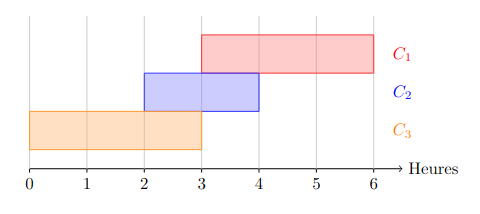
Ici on prendrait que $C_2$ au lieu de $C_1$ et $C_3$

### 2.3
!!! example Stratégie gloutonne 3
On classe les conférenciers par ordre **croissant d'heure de fin** de conférence.
!!!
!!! question Question 8
Reprenez votre fonction de tri pour en faire une fonction `tri_fin_croissant(reservations)`.
!!!

In [50]:
i_debut = 1
i_fin = 2
def merge_fin_croissant(l1, l2):
    i, j = 0, 0
    res = []
    while i < len(l1) and j < len(l2):
        if l1[i][i_fin] <= l2[j][i_fin] : 
            res.append(l1[i])
            i += 1
        else :
            res.append(l2[j])
            j += 1
    res += l1[i:] + l2[j:]
    return res

def tri_fin_croissant(reservations): # tri fusion O(n.log(n))
    if len(reservations) in [0,1]:
        return reservations
    mid = len(reservations)//2
    return merge_fin_croissant(tri_fin_croissant(reservations[:mid]), tri_fin_croissant(reservations[mid:]))

In [51]:
print(tri_fin_croissant(reservations_1))

[(2, 0, 1), (3, 1, 3), (4, 0, 3), (1, 2, 4)]


!!! question Question 9
Implémenter une fonciton `strat_3(reservations)` qui prend en paramètre une liste de réservations et renvoie une liste contenant les réservations prises en compte par la stratégie gloutonne 3. 
!!!

In [52]:
i_fin = 2

def strat_3(reservations):
    assert len(reservations) > 0, "la liste de réservations ne doit pas être vide"
    
    reservations = tri_fin_croissant(reservations)
    res = [reservations[0]]
    
    for i in range(1,len(reservations)):
        # si la dernière réservation prise est fini alors on peut prendre la reservation i
        if res[-1][i_fin] <= reservations[i][i_debut]:
            res.append(reservations[i])
    return res

In [53]:
print(strat_3([(1,3,6), (2,2,4), (3,0,3)]))

[(3, 0, 3), (1, 3, 6)]


!!! question Question 10
La stratégie gloutonne 3 est-elle optimale ? Si non, donner un exemple qui ne renvoie pas un résultat optimal.
!!!

Voici un exemple plus complèxe du problème : 

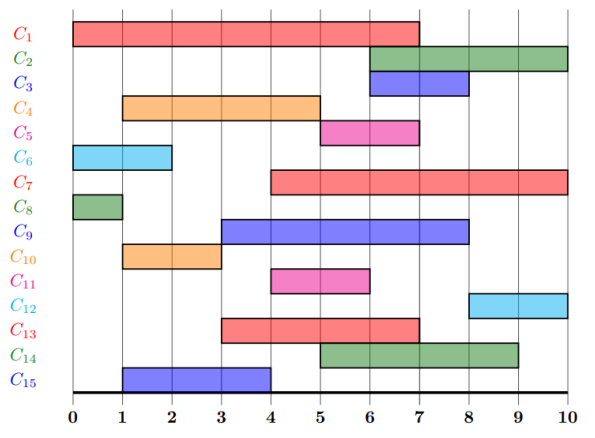

!!! question Question 11
Tester vos fonctions strat sur ces réservations.
!!!

In [54]:
r = [
    (1,0,7),
    (2,6,10),
    (3,6,8),
    (4,1,5),
    (5,5,7),
    (6,0,2),
    (7,4,10),
    (8,0,1),
    (9,3,8),
    (10,1,3),
    (11,4,6),
    (12,8,10),
    (13,3,7),
    (14,5,9),
    (15,1,4)
]

print(strat_1(r))
print(strat_2(r))
print(strat_3(r))

[(1, 0, 7), (12, 8, 10)]
[(8, 0, 1), (3, 6, 8), (10, 1, 3), (11, 4, 6), (12, 8, 10)]
[(8, 0, 1), (10, 1, 3), (11, 4, 6), (3, 6, 8), (12, 8, 10)]


## 3. Allocation de salles de cours

!!! info 
Maintenant, vous êtes à la direction d'un établissement scolaire et il est l'heure d'attribuer des salles de cours aux différents cours prévus.

Vous recevez toujours un planning de demandes de créneaux (les heures de cours d'une journée) mais ici, vous devez  installer tous ces cours dans des salles de classe. 

Ce que vous souhaitez optimiser, c'est le nombre de salles nécessaires. Vous voulez utiliser le **moins de salles possibles** pour que les cours aient lieu.
!!!

!!! example stratégie gloutonne optimal
La stratégie gloutonne 3 de la partie précédente peut être enrichie pour fournir une stratégie gloutonne optimale à ce problème. 

Voici l'algorithme que cela donne :
- On ordonne les cours par heure croissante de fin de cours.
- On place le premier cours (pour cet ordre établi) dans la première salle.
- On traite les cours suivants dans cet ordre établi en première étape. Pour chaque cours :
    - Si ce cours peut être placé dans une salle déjà utilisée, on le place dans la première salle possible (dans l'ordre d'ouverture de celle-ci).
    - Sinon, on ouvre une salle et on y place ce cours.
    
!!!
!!! info Modélisation
On représente un cours comme une réservation par le 3-uplet (id, debut, fin).

On représente le `planning` des salle comme une liste de liste de cours. Où `planning[i]` est la i-ème salle de cours.
!!!

!!! question Question 12
Écrire une fonction `affecte_salles(liste_cours)` prenant en entrée une liste de cours, et renvoyant en sortie le planning obtenu en appliquant la stratégie ci-dessus.
!!!

In [57]:
i_debut = 1
i_fin = 2

def affecte_salles(liste_cours):
    assert len(liste_cours) > 0, "la liste de cours ne doit pas être vide"
    
    liste_cours = tri_fin_croissant(liste_cours)
    planning = [[liste_cours[0]]]
    
    for j in range(1, len(liste_cours)) :
        i = 0
        while i < len(planning) :
            if liste_cours[j][i_debut] >= planning[i][-1][i_fin] :
                planning[i].append(liste_cours[j])
                break
            i += 1
        if i == len(planning):
            planning.append([liste_cours[j]])
            
    return planning
    

In [58]:
print(affecte_salles(r))

[[(8, 0, 1), (10, 1, 3), (11, 4, 6), (3, 6, 8), (12, 8, 10)], [(6, 0, 2), (5, 5, 7)], [(15, 1, 4), (14, 5, 9)], [(4, 1, 5), (2, 6, 10)], [(1, 0, 7)], [(13, 3, 7)], [(9, 3, 8)], [(7, 4, 10)]]


!!! question Question 13
Déterminer combien de salles est nécessaire pour ces cours : 

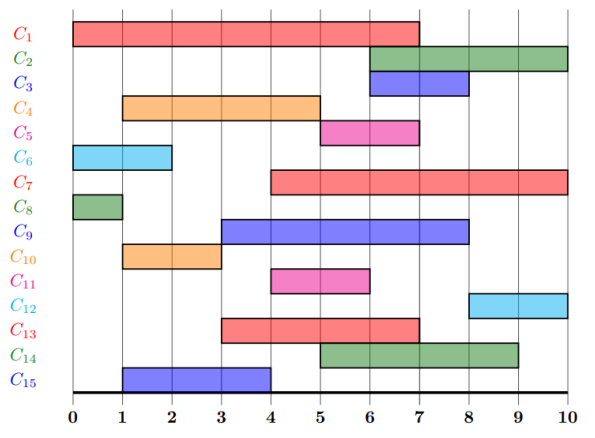

!!!

In [59]:
l_c = [
    (1,0,7),
    (2,6,10),
    (3,6,8),
    (4,1,5),
    (5,5,7),
    (6,0,2),
    (7,4,10),
    (8,0,1),
    (9,3,8),
    (10,1,3),
    (11,4,6),
    (12,8,10),
    (13,3,7),
    (14,5,9),
    (15,1,4)
]
print(len(affecte_salles(r)))

8
